# IEEE-CIS Fraud Detection: Dataset Audit

## Objective

Understand the structure, scale, target distribution, temporal characteristics,
missingness, and relationships within the IEEE-CIS Fraud Detection dataset
before developing any predictive model.

## Questions

1. What does one observation represent?
2. How large are the transaction and identity datasets?
3. How is the transaction table related to the identity table?
4. How prevalent is fraud?
5. How are transactions distributed over time?
6. How much missing information exists?
7. Which feature groups are available?
8. What potential sources of leakage exist?

## Principle

No modeling decisions will be made before the dataset has been properly audited.

In [1]:
%load_ext sql

In [2]:
import duckdb

import pandas as pd

conn = duckdb.connect()
%sql conn --alias duckdb
%config SqlMagic.displaylimit = 200

In [3]:
%%sql

CREATE OR REPLACE VIEW train_transaction AS SELECT * FROM read_csv_auto('../data/raw/train_transaction.csv');

CREATE OR REPLACE VIEW train_identity AS SELECT * FROM read_csv_auto('../data/raw/train_identity.csv');

CREATE OR REPLACE VIEW test_transaction AS SELECT * FROM read_csv_auto('../data/raw/test_transaction.csv');

CREATE OR REPLACE VIEW test_identity AS SELECT * FROM read_csv_auto('../data/raw/test_identity.csv');

CREATE OR REPLACE VIEW sample_submission AS SELECT * FROM read_csv_auto('../data/raw/sample_submission.csv');

Running query in 'duckdb'

Count


In [4]:
%%sql

SHOW TABLES;

Running query in 'duckdb'

name
sample_submission
test_identity
test_transaction
train_identity
train_transaction


In [5]:
%%sql

SELECT *
FROM train_transaction
LIMIT 5;

Running query in 'duckdb'

TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
2987000,0,86400,68.5,W,13926,None,150.0,discover,142.0,credit,315.0,87.0,19.0,None,None,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,None,13.0,None,None,None,None,None,None,13.0,13.0,None,None,None,0.0,True,True,True,M2,False,True,None,None,None,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,None,None,gmail.com,None,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,None,None,0.0,None,None,None,None,None,0.0,None,None,None,None,0.0,None,None,None,M0,True,True,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.

In [6]:
%%sql

SELECT COUNT(*) AS row_count
FROM train_transaction

Running query in 'duckdb'

row_count
590540


In [7]:
%%sql

SELECT * 
FROM test_transaction
LIMIT 5;


Running query in 'duckdb'

TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,None,gmail.com,None,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,None,None,None,None,418.0,203.0,None,None,None,409.0,True,True,False,None,None,False,True,True,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,47.95000076293945,0.0,0.0,47.95000076293945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.95000076293945,0.0,0.0,47.95000076293945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3663550,18403263,49.0,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,None,aol.com,None,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,None,None,None,None,231.0,634.0,None,None,None,634.0,True,False,False,M0,None,False,None,None,None,1.0,1.0,1.0,1.0,1.0,1.

In [8]:
%%sql

SELECT COUNT(*) AS row_count
FROM test_transaction

Running query in 'duckdb'

row_count
506691


In [9]:
%%sql

SELECT * 
FROM train_identity
LIMIT 5;

Running query in 'duckdb'

TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
2987004,0.0,70787.0,None,None,None,None,None,None,None,None,100.0,NotFound,None,-480.0,New,NotFound,166.0,None,542.0,144.0,None,None,None,None,None,None,None,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,True,False,True,True,mobile,SAMSUNG SM-G892A Build/NRD90M
2987008,-5.0,98945.0,None,None,0.0,-5.0,None,None,None,None,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,None,621.0,500.0,None,None,None,None,None,None,None,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,True,False,False,True,mobile,iOS Device
2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,None,None,0.0,0.0,100.0,NotFound,52.0,None,Found,Found,121.0,None,410.0,142.0,None,None,None,None,None,None,None,Found,Found,None,chrome 62.0,None,None,None,False,False,True,True,desktop,Windows
2987011,-5.0,221832.0,None,None,0.0,-6.0,None,None,None,None,100.0,NotFound,52.0,None,New,NotFound,225.0,None,176.0,507.0,None,None,None,None,None,None,None,New,NotFound,None,chrome 62.0,None,None,None,False,False,True,True,desktop,None
2987016,0.0,7460.0,0.0,0.0,1.0,0.0,None,None,0.0,0.0,100.0,NotFound,None,-300.0,Found,Found,166.0,15.0,529.0,575.0,None,None,None,None,None,None,None,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,True,False,True,True,desktop,MacOS


In [10]:
%%sql
SELECT COUNT(*) AS row_count
FROM train_identity

Running query in 'duckdb'

row_count
144233


In [11]:
%%sql

SELECT *
FROM test_identity
LIMIT 5;

Running query in 'duckdb'

TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
3663586,-45.0,280290.0,None,None,0.0,0.0,None,None,None,None,100.0,NotFound,27.0,None,New,NotFound,225.0,15.0,427.0,563.0,None,None,None,None,None,None,None,New,NotFound,None,chrome 67.0 for android,None,None,None,False,False,True,False,mobile,MYA-L13 Build/HUAWEIMYA-L13
3663588,0.0,3579.0,0.0,0.0,0.0,0.0,None,None,0.0,0.0,100.0,Found,None,-300.0,Found,Found,166.0,None,542.0,368.0,None,None,None,None,None,None,None,Found,Found,Android 6.0.1,chrome 67.0 for android,24.0,1280x720,match_status:2,True,False,True,True,mobile,LGLS676 Build/MXB48T
3663597,-5.0,185210.0,None,None,1.0,0.0,None,None,None,None,100.0,NotFound,52.0,-360.0,New,NotFound,225.0,None,271.0,507.0,None,None,None,None,None,None,None,New,NotFound,None,ie 11.0 for tablet,None,None,None,False,True,True,False,desktop,Trident/7.0
3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,None,None,0.0,0.0,100.0,NotFound,27.0,None,Found,Found,225.0,15.0,427.0,563.0,None,None,None,None,None,None,None,Found,Found,None,chrome 67.0 for android,None,None,None,False,False,True,False,mobile,MYA-L13 Build/HUAWEIMYA-L13
3663602,-95.0,328680.0,None,None,7.0,-33.0,None,None,None,None,100.0,NotFound,27.0,None,New,NotFound,225.0,15.0,567.0,507.0,None,None,None,None,None,None,None,New,NotFound,None,chrome 67.0 for android,None,None,None,False,False,True,False,mobile,SM-G9650 Build/R16NW


In [12]:
%%sql

SELECT COUNT(*) AS row_count
FROM test_identity

Running query in 'duckdb'

row_count
141907


In [13]:
%%sql

SELECT *
FROM sample_submission
LIMIT 5;

Running query in 'duckdb'

TransactionID,isFraud
3663549,0.5
3663550,0.5
3663551,0.5
3663552,0.5
3663553,0.5


In [14]:
%%sql 

SELECT COUNT(*) AS row_count
FROM sample_submission;

Running query in 'duckdb'

row_count
506691


In [15]:
%%sql

SELECT
    TransactionID,
    TransactionDT,
    TransactionAmt,
    ProductCD,
    card1,
    addr1,
    isFraud
FROM train_transaction
LIMIT 5;

Running query in 'duckdb'

TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,addr1,isFraud
2987000,86400,68.5,W,13926,315.0,0
2987001,86401,29.0,W,2755,325.0,0
2987002,86469,59.0,W,4663,330.0,0
2987003,86499,50.0,W,18132,476.0,0
2987004,86506,50.0,H,4497,420.0,0


In [16]:
%%sql
-- Determines whether unique identifiers are really unique
SELECT 
    COUNT(*) AS row_count,
    COUNT(DISTINCT TransactionID) as count_of_unique_id
FROM train_transaction


Running query in 'duckdb'

row_count,count_of_unique_id
590540,590540


In [17]:
%%sql 
SELECT 
    COUNT(*) AS transactional_rows,
    COUNT(i.TransactionID) AS transaction_with_identity
FROM train_transaction t 
LEFT JOIN train_identity i
    ON t.TransactionID = i.TransactionID;

Running query in 'duckdb'

transactional_rows,transaction_with_identity
590540,144233


In [18]:
%%sql 
-- Determines the uniqueness inside train_identity

SELECT
    COUNT(*) AS identity_rows,
    COUNT(DISTINCT TransactionID) AS unique_transaction_ids
FROM train_identity;

Running query in 'duckdb'

identity_rows,unique_transaction_ids
144233,144233


In [19]:
%%sql

-- Checks for duplicates  in TransactionID

SELECT
    TransactionID,
    COUNT(*) AS occurrences
FROM train_identity
GROUP BY TransactionID
HAVING COUNT(*) > 1
ORDER BY occurrences DESC
LIMIT 10;

Running query in 'duckdb'

TransactionID,occurrences


In [20]:
%%sql

-- Determines the number of columns per table

SELECT
    table_name,
    COUNT(*) AS column_count
FROM information_schema.columns
WHERE table_name IN ('train_transaction', 'test_transaction', 'train_identity', 'test_identity', 'sample_submission')
GROUP BY table_name
ORDER BY column_count DESC;

Running query in 'duckdb'

table_name,column_count
train_transaction,394
test_transaction,393
train_identity,41
test_identity,41
sample_submission,2


In [21]:
%%sql

SELECT 'train_transaction' AS table_name, COUNT(*) AS row_count
FROM train_transaction
UNION ALL
SELECT 'train_identity', COUNT(*)
FROM train_identity
UNION ALL
SELECT 'test_transaction', COUNT(*)
FROM test_transaction
UNION ALL
SELECT 'test_identity', COUNT(*)
FROM test_identity
UNION ALL
SELECT 'sample_submission', COUNT(*)
FROM sample_submission
ORDER BY row_count DESC;

Running query in 'duckdb'

table_name,row_count
train_transaction,590540
test_transaction,506691
sample_submission,506691
train_identity,144233
test_identity,141907


### Fraud Prevalence

In [22]:
%%sql

-- Calculates the imbalance ratio

SELECT
    isFraud,
    COUNT(*) AS transaction_count,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        4
    ) AS percentage
FROM train_transaction
GROUP BY isFraud
ORDER BY isFraud;

Running query in 'duckdb'

isFraud,transaction_count,percentage
0,569877,96.501
1,20663,3.499


### Distribution of transactions and Fraud  over time

In [23]:
%%sql

SELECT
    MIN(TransactionDT) AS min_transaction_dt,
    MAX(TransactionDT) AS max_transaction_dt,
    COUNT(DISTINCT TransactionDT) AS unique_transaction_dt
FROM 
    train_transaction

Running query in 'duckdb'

min_transaction_dt,max_transaction_dt,unique_transaction_dt
86400,15811131,573349


In [24]:
%%sql
-- Calculates the minimum and maximun duration of transactions in seconds and days
--A day has 86,400 seconds
SELECT
    MIN(TransactionDT) AS min_dt,
    MAX(TransactionDT) AS max_dt,
    MAX(TransactionDT) - MIN(TransactionDT) AS duration_seconds,
    ROUND((MAX(TransactionDT) - MIN(TransactionDT)) / 86400, 2) AS duration_days
FROM train_transaction;

Running query in 'duckdb'

min_dt,max_dt,duration_seconds,duration_days
86400,15811131,15724731,182.0


In [25]:
%%sql

-- Creates a view for daily transactions that spans for 182 days thats nearly 6 months

CREATE OR REPLACE VIEW daily_transaction_summary AS
SELECT
    FLOOR(TransactionDT / 86400) AS day,
    COUNT(*) AS transaction_count,
    ROUND(SUM(TransactionAmt), 3) AS transaction_amt_dollars,
    SUM(isFraud) AS fraud_count,
    ROUND(AVG(isFraud) * 100, 3) AS fraud_rate_pct,
    ROUND(SUM(CASE WHEN isFraud =1 THEN TransactionAmt ELSE 0 END), 3) AS fraud_amt_dollars
    
FROM train_transaction
GROUP BY day
ORDER BY day

Running query in 'duckdb'

Count


In [26]:
# Displays all the daily transactions
query =""" 
SELECT *
FROM daily_transaction_summary
ORDER BY day
"""
trends = conn.execute(query).df()
display(trends.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,day,transaction_count,transaction_amt_dollars,fraud_count,fraud_rate_pct,fraud_amt_dollars
0,1.0,5122,742186.931,112.0,2.187,20337.144
1,2.0,3730,453400.013,123.0,3.298,15359.607
2,3.0,3241,348517.434,92.0,2.839,14254.337
3,4.0,4036,515968.997,115.0,2.849,14120.447
4,5.0,3964,543140.641,127.0,3.204,16692.721
5,6.0,3717,476860.620,99.0,2.663,12869.080
6,7.0,3786,534372.081,136.0,3.592,21670.363
7,8.0,3999,546577.819,93.0,2.326,13508.152
8,9.0,3907,456672.979,119.0,3.046,13106.598
9,10.0,3445,355377.377,90.0,2.612,12709.721


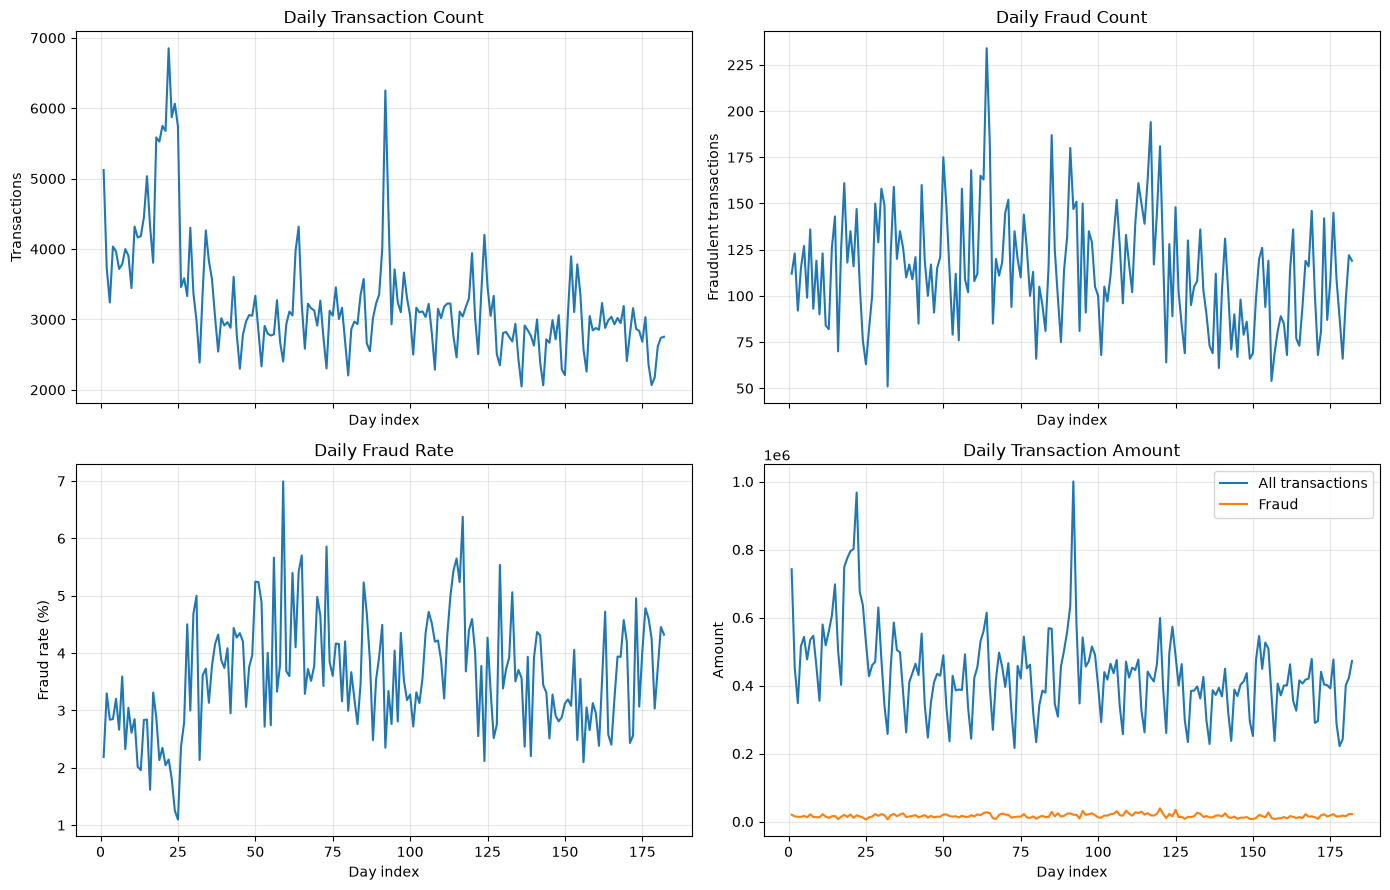

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

axes[0, 0].plot(trends["day"], trends["transaction_count"])
axes[0, 0].set_title("Daily Transaction Count")
axes[0, 0].set_ylabel("Transactions")

axes[0, 1].plot(trends["day"], trends["fraud_count"])
axes[0, 1].set_title("Daily Fraud Count")
axes[0, 1].set_ylabel("Fraudulent transactions")

axes[1, 0].plot(trends["day"], trends["fraud_rate_pct"])
axes[1, 0].set_title("Daily Fraud Rate")
axes[1, 0].set_ylabel("Fraud rate (%)")

axes[1, 1].plot(trends["day"], trends["transaction_amt_dollars"], label="All transactions")
axes[1, 1].plot(trends["day"], trends["fraud_amt_dollars"], label="Fraud")
axes[1, 1].set_title("Daily Transaction Amount")
axes[1, 1].set_ylabel("Amount")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("Day index")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [28]:
# Daily Transaction Volume variation 
query = """ 
SELECT
    MIN(transaction_count) AS min_transactions,
    MAX(transaction_count) AS max_transactions,
    ROUND(AVG(transaction_count), 3) AS avg_transactions,
    ROUND(SUM(transaction_amt_dollars),3) AS total_amt_transacted$,
    ROUND(SUM(fraud_amt_dollars), 3) AS total_fraud_amt_transacted$
FROM daily_transaction_summary;
"""

volume_variation = conn.execute(query).df()

with pd.option_context("display.float_format", "{:,.3f}".format):
    display(volume_variation.T)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
min_transactions,"2,048.000"
max_transactions,"6,852.000"
avg_transactions,"3,244.725"
total_amt_transacted$,"79,738,948.735"
total_fraud_amt_transacted$,"3,083,844.860"


In [29]:
%%sql

-- Daily Fraud Transaction Variation

SELECT
    MIN(fraud_amt_dollars) AS min_fraud_amount,
    MAX(fraud_amt_dollars) AS max_fraud_amount,
    ROUND(AVG(fraud_amt_dollars),3) AS AVG_fraud_amount
FROM
    daily_transaction_summary

Running query in 'duckdb'

min_fraud_amount,max_fraud_amount,AVG_fraud_amount
5965.498,39055.2,16944.203


In [30]:
%%sql
-- Finds the top 10 highest transaction amount
SELECT *
FROM 
    daily_transaction_summary
ORDER BY transaction_amt_dollars DESC
LIMIT 10;

Running query in 'duckdb'

day,transaction_count,transaction_amt_dollars,fraud_count,fraud_rate_pct,fraud_amt_dollars
92.0,6252,1000660.4,147,2.351,20016.558
22.0,6852,967887.459,147,2.145,18677.983
21.0,5677,801712.829,116,2.043,11047.986
20.0,5749,795644.64,135,2.348,20877.602
19.0,5526,775397.377,118,2.135,13647.861
18.0,5585,749349.635,161,2.883,19745.874
1.0,5122,742186.931,112,2.187,20337.144
15.0,5034,697884.615,143,2.841,16438.681
23.0,5872,675913.835,106,1.805,15191.024
24.0,6065,636713.772,76,1.253,11902.088


In [31]:
%%sql
-- Finds the top 10 highest fraudulent amount amount
SELECT *
FROM 
    daily_transaction_summary
ORDER BY fraud_amt_dollars DESC
LIMIT 10;

Running query in 'duckdb'

day,transaction_count,transaction_amt_dollars,fraud_count,fraud_rate_pct,fraud_amt_dollars
120.0,3941,598865.311,181,4.593,39055.2
125.0,3467,489319.958,148,4.269,34599.427
109.0,3151,470397.391,133,4.221,32184.507
95.0,3711,541885.931,150,4.042,31478.149
106.0,3221,475316.653,152,4.719,30852.047
114.0,2758,325622.347,150,5.439,29092.988
85.0,3574,567179.937,187,5.232,28536.539
64.0,4317,614500.449,234,5.42,27517.518
112.0,3225,445948.993,139,4.31,27171.119
155.0,3352,508477.424,119,3.55,26956.384


In [32]:
query ="""
SELECT
    COUNT(*) AS observed_days,

    SUM(transaction_count) AS total_transactions,
    SUM(fraud_count) AS total_fraud,

    ROUND(AVG(transaction_count), 2) AS avg_daily_transactions,
    MIN(transaction_count) AS min_daily_transactions,
    MAX(transaction_count) AS max_daily_transactions,

    ROUND(AVG(fraud_count), 2) AS avg_daily_fraud,
    MIN(fraud_count) AS min_daily_fraud,
    MAX(fraud_count) AS max_daily_fraud,

    ROUND(MIN(fraud_rate_pct), 3) AS min_daily_fraud_rate_pct,
    ROUND(MAX(fraud_rate_pct), 3) AS max_daily_fraud_rate_pct,
    ROUND(AVG(fraud_rate_pct), 3) AS mean_daily_fraud_rate_pct
FROM daily_transaction_summary;
"""
df = conn.execute(query).df()
df.T

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
observed_days,182.000
total_transactions,590540.000
total_fraud,20663.000
avg_daily_transactions,3244.730
min_daily_transactions,2048.000
max_daily_transactions,6852.000
avg_daily_fraud,113.530
min_daily_fraud,51.000
max_daily_fraud,234.000
min_daily_fraud_rate_pct,1.097


### The Missing Information

In [33]:
query = """SELECT * FROM train_transaction"""
train_transaction = conn.execute(query).df()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
import missingno as msno

def visualize_missingness(df: pd.DataFrame, sample_size: int = 5000) -> None:
    """
    Generates missing data visualization using missingno
    Uses sampling to prevent memory crashes on large datasets
    """

    msno.heatmap(df, figsize=(12,6))
    plt.title("Nullity Correlation Heatmap", fontsize = 12)
    plt.show()
visualize_missingness(train_transaction)




KeyboardInterrupt: 

In [34]:
%%sql
SELECT
    COUNT(*) AS total_columns,
    COUNT(*) FILTER (WHERE column_name != 'isFraud') AS feature_columns
FROM (DESCRIBE train_transaction);

Running query in 'duckdb'

total_columns,feature_columns
394,393


In [37]:
%%sql

SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(TransactionID) AS missing_TransactionID,
    COUNT(*) - COUNT(TransactionDT) AS missing_TransactionDT,
    COUNT(*) - COUNT(TransactionAmt) AS missing_TransactionAmt,
    COUNT(*) - COUNT(ProductCD) AS missing_ProductCD
FROM train_transaction;

Running query in 'duckdb'

total_rows,missing_TransactionID,missing_TransactionDT,missing_TransactionAmt,missing_ProductCD
590540,0,0,0,0


In [ ]:
# Establishes where the missingness is and its magnitude

query = "SUMMARIZE train_transaction"
summary = conn.execute(query).df()
null_summary = summary[["column_name", "null_percentage"]]
null_summary = null_summary[null_summary["null_percentage"]>0]
with pd.option_context("display.max_rows", None):
    display(null_summary.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,null_percentage
6,card2,1.51
7,card3,0.27
8,card4,0.27
9,card5,0.72
10,card6,0.27


In [ ]:
# Determines how spread is the data

null_summary["missing_group"] = pd.cut(
    null_summary["null_percentage"],
    bins=[0, 10, 50, 80, 100],
    labels=[
        "Low (<10%)",
        "Moderate (10–<50%)",
        "High (50–80%)",
        "Very high (>80%)",
        ],
    right=False,
)

display(null_summary["missing_group"].value_counts().sort_index())

missing_group
Low (<10%)             60
Moderate (10–<50%)    108
High (50–80%)         119
Very high (>80%)       55
Name: count, dtype: int64

### Relationship between missingness and fraud

In [61]:
%%sql

SELECT
    isFraud,
    COUNT(*) AS transactions,
    COUNT(*) - COUNT(dist2) AS missing_count,
    ROUND(
        (COUNT(*) - COUNT(dist2)) * 100.0 / COUNT(*),
        2
    ) AS missing_pct
FROM train_transaction
GROUP BY isFraud
ORDER BY isFraud;

Running query in 'duckdb'

isFraud,transactions,missing_count,missing_pct
0,569877,535981,94.05
1,20663,16932,81.94
